# Gold: métricas de crescimento (`governor_growth_metrics`)

ADR [0022](../../docs/adr/0022-notebooks-de-diagnostico-medallion-separados-da-narrativa-do-tcc.md)
(issue [#128](https://github.com/Vini0606/Tecnicas-de-Ciencia-de-Dados-em-dados-do-Instagram/issues/128)).
Diagnóstico de `governor_growth_metrics` -- CMGR de audiência (`followersCount`) e retenção de
sentimento positivo, calculados sobre `governor_engagement_history`/`governor_sentiment_history`
(`src/modeling/growth_history.py`, escrita via `scripts/run_growth_metrics.py`).

**`ilustrativo`/`nota` são o "selo de confiabilidade" desta tabela** (ver `CONTEXT.md`): `True`
sempre que `cmgr_confiavel` ou `retencao_confiavel` for `False` por poucas execuções acumuladas
ainda. Qualquer leitura de `cmgr`/`retencao` abaixo precisa checar essas duas colunas antes de
tratar um valor como conclusivo -- é uma limitação de tempo de operação, não um bug.

Notebook estritamente leitura via `DeltaRepository`, mesmo princípio da ADR
[0003](../../docs/adr/0003-desacoplar-modelagem-do-notebook-via-scripts-cli-com-checkpoint.md).

**Nota**: esta tabela não tinha dado local no ambiente em que este notebook foi escrito -- a célula
de carga abaixo levanta um erro explícito nesse caso, em vez de seguir com um DataFrame vazio
disfarçado de "sem achados".

In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from config import settings
from src.repositories.delta_repository import DeltaRepository
from src.analysis.medallion_diagnostics import (
    completeness_summary,
    count_duplicate_rows,
    with_governor_metadata,
)

load_dotenv()
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

repo = DeltaRepository(gold_dir=settings.GOLD_DIR, silver_dir=settings.SILVER_DIR)

## 1. Carga + schema

In [2]:
try:
    df_growth = repo.load_growth_metrics()
except FileNotFoundError as e:
    raise RuntimeError(
        'governor_growth_metrics sem dado local -- rode scripts/run_growth_metrics.py primeiro '
        '(lê governor_engagement_history/governor_sentiment_history via DeltaRepository, escreve '
        'esta tabela). Detalhe original: ' + str(e)
    ) from e
df_growth.dtypes

inputUrl                                 object
valor_inicial                           float64
valor_final                             float64
cmgr                                    float64
cmgr_n_periodos                           int64
cmgr_confiavel                             bool
cmgr_motivo                              object
retencao                                float64
retencao_n_periodos                       int64
retencao_n_pares_validos                  int64
retencao_confiavel                         bool
retencao_motivo                          object
ilustrativo                                bool
nota                                     object
_run_id                                  object
_generated_at               datetime64[us, UTC]
dtype: object

## 2. Completude

`cmgr`/`retencao`/`valor_inicial`/`valor_final` são `nullable=True` por contrato de schema (podem
ser `NaN` quando não calculáveis) -- nulo aqui não é erro de dado, é o valor esperado para um perfil
sem histórico suficiente ainda.

In [3]:
completude = completeness_summary(df_growth)
print(f"linhas duplicadas (por inputUrl): {count_duplicate_rows(df_growth, subset=['inputUrl'])}")
completude[completude['n_nulos'] > 0]

linhas duplicadas (por inputUrl): 0


,coluna,dtype,n_nulos,pct_nulos,n_unicos
3,cmgr,float64,27,100.0000,0
7,retencao,float64,27,100.0000,0
11,retencao_motivo,object,1,3.7037,1


## 3. Distribuições univariadas: quantas execuções, e o selo de confiabilidade

Antes de plotar `cmgr`/`retencao` em si, vale ver **quantos perfis já são `confiavel`** -- se a
maioria ainda for `ilustrativo`, qualquer distribuição abaixo é preliminar por definição.

In [4]:
print('cmgr_confiavel:')
print(df_growth['cmgr_confiavel'].value_counts())
print()
print('retencao_confiavel:')
print(df_growth['retencao_confiavel'].value_counts())
print()
print(f"{df_growth['ilustrativo'].mean() * 100:.1f}% das linhas são ilustrativo=True")

cmgr_confiavel:
cmgr_confiavel
False    27
Name: count, dtype: int64

retencao_confiavel:
retencao_confiavel
False    27
Name: count, dtype: int64

100.0% das linhas são ilustrativo=True


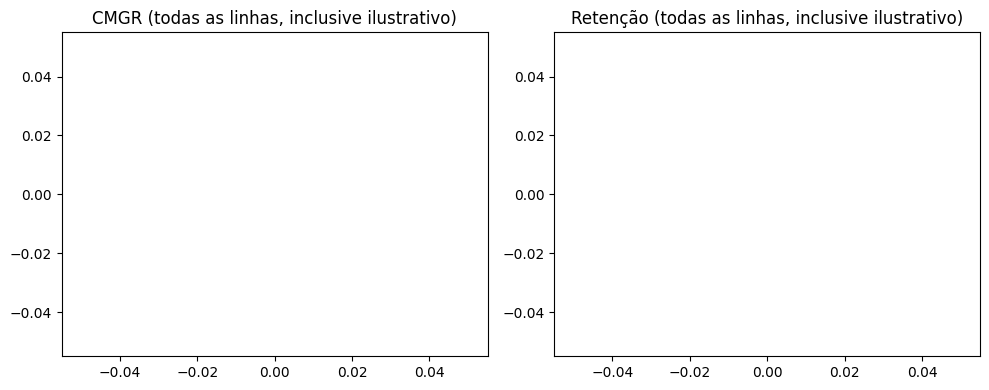

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df_growth['cmgr'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('CMGR (todas as linhas, inclusive ilustrativo)')
sns.histplot(df_growth['retencao'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Retenção (todas as linhas, inclusive ilustrativo)')
plt.tight_layout()
plt.show()

## 4. Evolução temporal

Sem tabela `_history` irmã para `governor_growth_metrics` -- ela É a agregação sobre o histórico de
outras tabelas, então uma "evolução do CMGR" precisaria comparar execuções diferentes desta própria
tabela ao longo do tempo (não coberto pelo esqueleto padrão de `_history`, fora de escopo aqui).

## 5. Relação com covariáveis (partido/UF)

Só entre linhas `cmgr_confiavel` -- misturar `ilustrativo` no agrupamento por partido distorceria a
comparação com ruído de perfis que ainda não acumularam histórico.

0 de 27 perfis com cmgr_confiavel=True


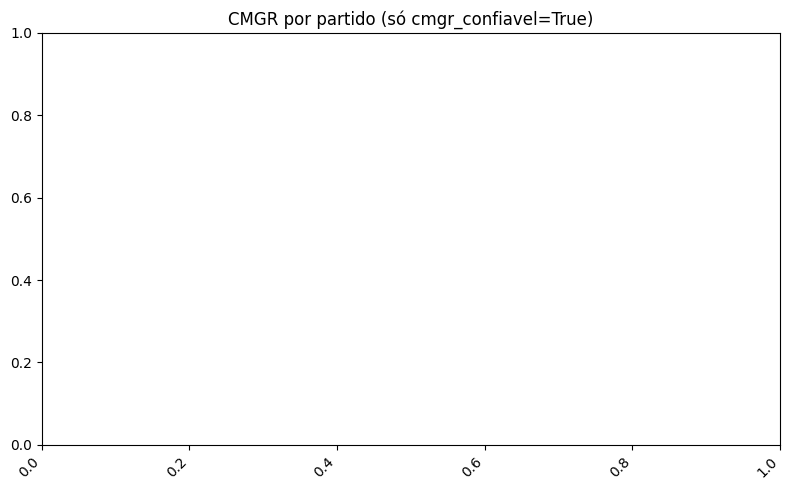

In [6]:
df_com_metadado = with_governor_metadata(df_growth, repo.load_governors_metadata())
df_confiavel = df_com_metadado[df_com_metadado['cmgr_confiavel']]
print(f'{len(df_confiavel)} de {len(df_com_metadado)} perfis com cmgr_confiavel=True')

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_confiavel, x='partido', y='cmgr', ax=ax)
ax.set_title('CMGR por partido (só cmgr_confiavel=True)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Outliers

CMGR extremo (positivo ou negativo) entre os perfis já `confiavel` -- excluir `ilustrativo` aqui de
propósito, um valor "outlier" com poucas execuções não é distinguível de ruído estatístico.

In [7]:
media = df_confiavel['cmgr'].mean()
desvio = df_confiavel['cmgr'].std()
outliers = df_confiavel[(df_confiavel['cmgr'] - media).abs() > 2 * desvio]
print(f'{len(outliers)} perfis confiáveis fora de 2 desvios-padrão de CMGR (média={media:.4f}, desvio={desvio:.4f})')
outliers[['nome', 'partido', 'cmgr', 'cmgr_n_periodos', 'retencao', 'retencao_confiavel']]

0 perfis confiáveis fora de 2 desvios-padrão de CMGR (média=nan, desvio=nan)


,nome,partido,cmgr,cmgr_n_periodos,retencao,retencao_confiavel


## Nota de interpretação

Repetir este notebook periodicamente à medida que `data/gold/governor_engagement_history` acumula
mais execuções -- a pergunta útil não é "qual o CMGR hoje" enquanto a maioria for `ilustrativo`, e
sim "quantos perfis já viraram `confiavel` desde a última vez que rodei este notebook".